# 机器学习基础实验：线性回归与波士顿房价预测

本 Notebook 将完整演示从数据加载、探索分析、手动实现线性回归，到使用 sklearn 训练线性回归与岭回归模型，并完成房价预测应用。

说明：
- 数据集使用波士顿房价数据的公开 URL，替代已弃用的 `load_boston`
- 代码按照 Notebook 的执行顺序组织，可逐单元运行
- 为了更稳定地运行，手动线性回归使用最小二乘的 `lstsq` 实现

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings

warnings.filterwarnings('ignore')

plt.rcParams['font.sans-serif'] = ['SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

print('✅ 环境配置完成')

# 数据加载（替换已弃用的 load_boston）
data_url = 'http://lib.stat.cmu.edu/datasets/boston'
raw_df = pd.read_csv(data_url, sep='\s+', skiprows=22, header=None)

data_array = np.hstack([raw_df.values[::2, :], raw_df.values[1::2, :2]])
target = raw_df.values[1::2, 2]

feature_names = ['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT']

data = pd.DataFrame(data_array, columns=feature_names)
data['PRICE'] = target

print(f'✅ 数据加载完成，形状: {data.shape}')
print(data.head())

✅ 环境配置完成
✅ 数据加载完成，形状: (506, 14)
      CRIM    ZN  INDUS  CHAS    NOX     RM   AGE     DIS  RAD    TAX  \
0  0.00632  18.0   2.31   0.0  0.538  6.575  65.2  4.0900  1.0  296.0   
1  0.02731   0.0   7.07   0.0  0.469  6.421  78.9  4.9671  2.0  242.0   
2  0.02729   0.0   7.07   0.0  0.469  7.185  61.1  4.9671  2.0  242.0   
3  0.03237   0.0   2.18   0.0  0.458  6.998  45.8  6.0622  3.0  222.0   
4  0.06905   0.0   2.18   0.0  0.458  7.147  54.2  6.0622  3.0  222.0   

   PTRATIO       B  LSTAT  PRICE  
0     15.3  396.90   4.98   24.0  
1     17.8  396.90   9.14   21.6  
2     17.8  392.83   4.03   34.7  
3     18.7  394.63   2.94   33.4  
4     18.7  396.90   5.33   36.2  


## 步骤1：数据探索（EDA）

先查看样本规模、缺失值、统计描述和特征相关性，再用热力图与散点图观察房间数（RM）和房价之间的关系。


📊 步骤1：数据探索（EDA）

【数据基本信息】
样本数: 506, 特征数: 13
缺失值统计:
CRIM       0
ZN         0
INDUS      0
CHAS       0
NOX        0
RM         0
AGE        0
DIS        0
RAD        0
TAX        0
PTRATIO    0
B          0
LSTAT      0
PRICE      0
dtype: int64

【特征统计描述】
         CRIM      ZN   INDUS    CHAS     NOX      RM     AGE     DIS     RAD  \
count  506.00  506.00  506.00  506.00  506.00  506.00  506.00  506.00  506.00   
mean     3.61   11.36   11.14    0.07    0.55    6.28   68.57    3.80    9.55   
std      8.60   23.32    6.86    0.25    0.12    0.70   28.15    2.11    8.71   
min      0.01    0.00    0.46    0.00    0.38    3.56    2.90    1.13    1.00   
25%      0.08    0.00    5.19    0.00    0.45    5.89   45.02    2.10    4.00   
50%      0.26    0.00    9.69    0.00    0.54    6.21   77.50    3.21    5.00   
75%      3.68   12.50   18.10    0.00    0.62    6.62   94.07    5.19   24.00   
max     88.98  100.00   27.74    1.00    0.87    8.78  100.00   12.13   24.00   

          TAX

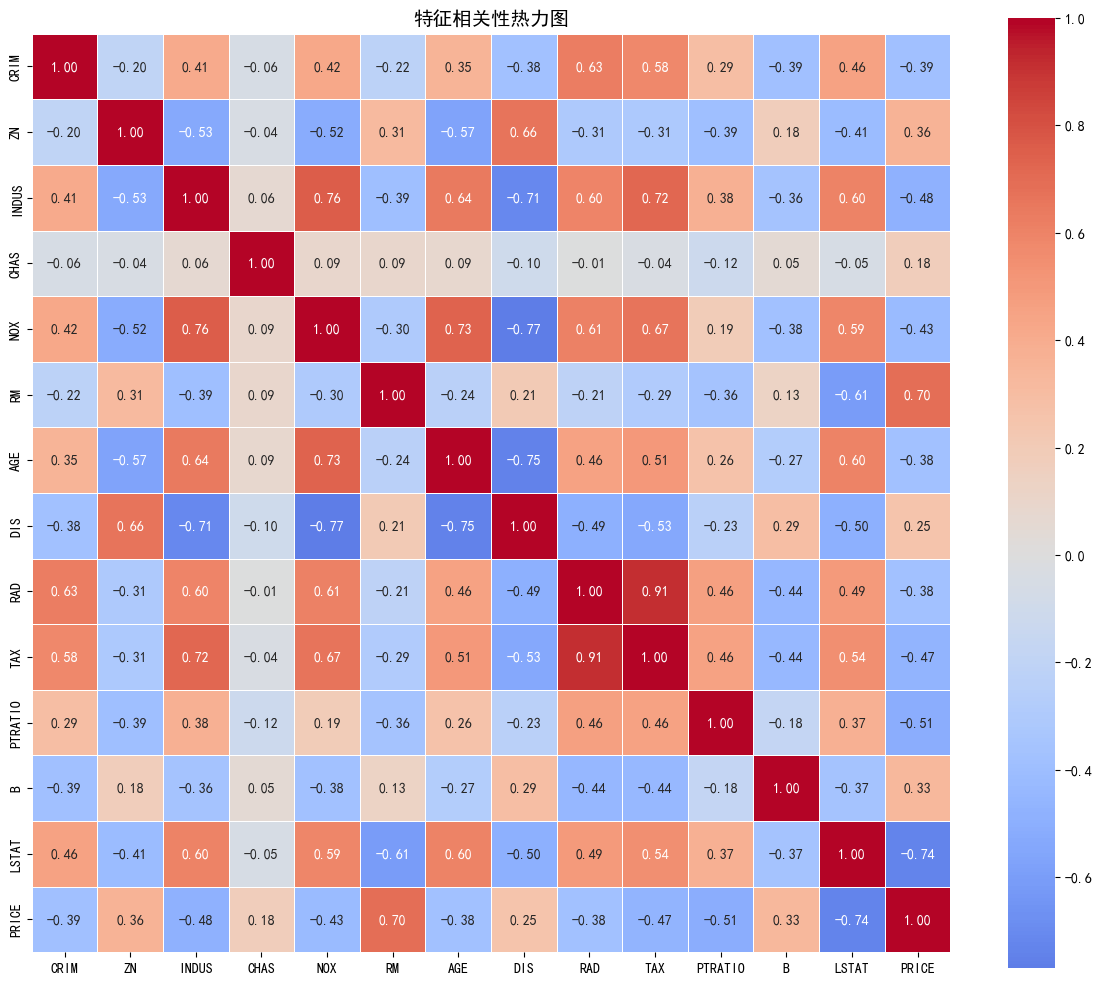

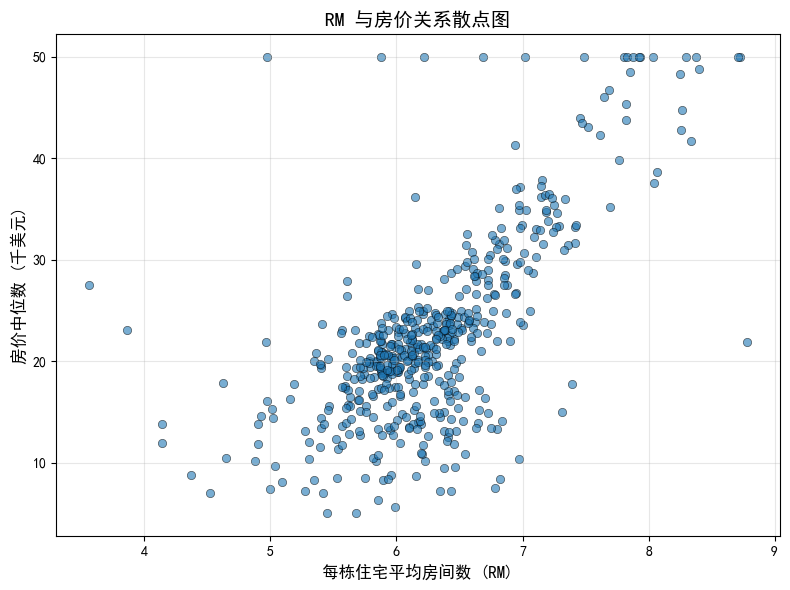


✅ 数据探索完成
关键发现：RM（房间数）与房价呈正相关，LSTAT（低收入人口占比）与房价呈负相关


In [7]:
print('\n' + '=' * 60)
print('📊 步骤1：数据探索（EDA）')
print('=' * 60)

print('\n【数据基本信息】')
print(f'样本数: {data.shape[0]}, 特征数: {data.shape[1] - 1}')
print(f'缺失值统计:\n{data.isnull().sum()}')

print('\n【特征统计描述】')
print(data.describe().round(2))

corr = data.corr(numeric_only=True)
print('\n【各特征与房价的相关系数（降序）】')
print(corr['PRICE'].sort_values(ascending=False))

plt.figure(figsize=(12, 10))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True, linewidths=0.5)
plt.title('特征相关性热力图', fontsize=14)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 6))
plt.scatter(data['RM'], data['PRICE'], alpha=0.6, edgecolors='black', linewidth=0.5)
plt.xlabel('每栋住宅平均房间数 (RM)', fontsize=12)
plt.ylabel('房价中位数 (千美元)', fontsize=12)
plt.title('RM 与房价关系散点图', fontsize=14)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print('\n✅ 数据探索完成')
print('关键发现：RM（房间数）与房价呈正相关，LSTAT（低收入人口占比）与房价呈负相关')

## 步骤2：数据预处理

将特征与标签拆分后，再划分训练集和测试集，并对特征进行标准化。

In [8]:
print('\n' + '=' * 60)
print('🔧 步骤2：数据预处理')
print('=' * 60)

X = data.drop('PRICE', axis=1)
y = data['PRICE']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f'训练集大小: {X_train.shape[0]} 样本')
print(f'测试集大小: {X_test.shape[0]} 样本')

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print('✅ 数据预处理完成（已标准化）')


def evaluate(y_true, y_pred, name='模型', silent=False):
    """计算并打印回归模型的评估指标。"""
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)

    if not silent:
        print(f'\n{name} 评估指标：')
        print(f'  MAE  (平均绝对误差): {mae:.4f} 千美元')
        print(f'  MSE  (均方误差):     {mse:.4f}')
        print(f'  RMSE (均方根误差):   {rmse:.4f} 千美元')
        print(f'  R²   (决定系数):     {r2:.4f}')

    return mae, mse, rmse, r2


🔧 步骤2：数据预处理
训练集大小: 404 样本
测试集大小: 102 样本
✅ 数据预处理完成（已标准化）


## 步骤3：手动实现线性回归

这里不用矩阵求逆，而是用最小二乘的 `lstsq` 方式求解，数值稳定性更好，也更适合 Notebook 演示。

In [9]:
print('\n' + '=' * 60)
print('✍️ 步骤3：手动实现线性回归（最小二乘法）')
print('=' * 60)


class MyLinearRegression:
    """手动实现线性回归。"""

    def __init__(self):
        self.w = None
        self.b = None

    def fit(self, X, y):
        X_mat = np.asarray(X, dtype=float)
        y_vec = np.asarray(y, dtype=float).reshape(-1, 1)
        X_b = np.c_[np.ones((X_mat.shape[0], 1)), X_mat]

        theta, *_ = np.linalg.lstsq(X_b, y_vec, rcond=None)
        self.b = float(theta[0, 0])
        self.w = theta[1:, 0]

    def predict(self, X):
        X_mat = np.asarray(X, dtype=float)
        return X_mat @ self.w + self.b


my_lr = MyLinearRegression()
my_lr.fit(X_train_scaled, y_train)
y_pred_my = my_lr.predict(X_test_scaled)

print('\n【手动实现线性回归 - 模型参数】')
print(f'截距 b: {my_lr.b:.4f}')
print(f'特征权重 w: {np.round(my_lr.w, 4)}')

print('\n【手动实现模型 - 前5个测试样本预测结果】')
for i in range(5):
    print(
        f'  样本{i + 1}: 真实房价 = {y_test.iloc[i]:.2f} 千美元 | '
        f'预测房价 = {y_pred_my[i]:.2f} 千美元 | '
        f'误差 = {abs(y_test.iloc[i] - y_pred_my[i]):.2f} 千美元'
    )

my_lr_metrics = evaluate(y_test, y_pred_my, '手动实现线性回归')


✍️ 步骤3：手动实现线性回归（最小二乘法）

【手动实现线性回归 - 模型参数】
截距 b: 22.7965
特征权重 w: [-1.0021  0.6963  0.2781  0.7187 -2.0223  3.1452 -0.176  -3.0819  2.2514
 -1.767  -2.0378  1.1296 -3.6117]

【手动实现模型 - 前5个测试样本预测结果】
  样本1: 真实房价 = 23.60 千美元 | 预测房价 = 29.00 千美元 | 误差 = 5.40 千美元
  样本2: 真实房价 = 32.40 千美元 | 预测房价 = 36.03 千美元 | 误差 = 3.63 千美元
  样本3: 真实房价 = 13.60 千美元 | 预测房价 = 14.82 千美元 | 误差 = 1.22 千美元
  样本4: 真实房价 = 22.80 千美元 | 预测房价 = 25.03 千美元 | 误差 = 2.23 千美元
  样本5: 真实房价 = 16.10 千美元 | 预测房价 = 18.77 千美元 | 误差 = 2.67 千美元

手动实现线性回归 评估指标：
  MAE  (平均绝对误差): 3.1891 千美元
  MSE  (均方误差):     24.2911
  RMSE (均方根误差):   4.9286 千美元
  R²   (决定系数):     0.6688


## 步骤4：sklearn 基线模型与岭回归调参

先训练基础线性回归，再使用网格搜索寻找最优的岭回归正则化系数。

In [10]:
print('\n' + '=' * 60)
print('📚 步骤4：sklearn 基线模型与岭回归调参')
print('=' * 60)

print('\n【4.1 sklearn 线性回归】')
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)

print(f'sklearn 线性回归 - 截距: {lr.intercept_:.4f}')
print(f'sklearn 线性回归 - 权重: {np.round(lr.coef_, 4)}')
lr_metrics = evaluate(y_test, y_pred_lr, 'sklearn 线性回归')

print('\n【4.2 岭回归 + 网格搜索调优】')
ridge = Ridge()
param_grid = {'alpha': [0.001, 0.01, 0.1, 1, 10, 100]}

grid = GridSearchCV(
    ridge,
    param_grid,
    cv=5,
    scoring='neg_mean_squared_error',
    return_train_score=True,
)
grid.fit(X_train_scaled, y_train)

print(f'最优正则化系数 alpha: {grid.best_params_["alpha"]}')
print(f'最佳交叉验证得分: {grid.best_score_:.4f}')

y_pred_best = grid.predict(X_test_scaled)
best_metrics = evaluate(y_test, y_pred_best, f'最优岭回归(alpha={grid.best_params_["alpha"]})')

print('\n【网格搜索所有结果】')
cv_results = pd.DataFrame(grid.cv_results_)
print(cv_results[['param_alpha', 'mean_test_score', 'std_test_score', 'rank_test_score']].to_string(index=False))


📚 步骤4：sklearn 基线模型与岭回归调参

【4.1 sklearn 线性回归】
sklearn 线性回归 - 截距: 22.7965
sklearn 线性回归 - 权重: [-1.0021  0.6963  0.2781  0.7187 -2.0223  3.1452 -0.176  -3.0819  2.2514
 -1.767  -2.0378  1.1296 -3.6117]

sklearn 线性回归 评估指标：
  MAE  (平均绝对误差): 3.1891 千美元
  MSE  (均方误差):     24.2911
  RMSE (均方根误差):   4.9286 千美元
  R²   (决定系数):     0.6688

【4.2 岭回归 + 网格搜索调优】
最优正则化系数 alpha: 1
最佳交叉验证得分: -23.6488

最优岭回归(alpha=1) 评估指标：
  MAE  (平均绝对误差): 3.1857 千美元
  MSE  (均方误差):     24.3129
  RMSE (均方根误差):   4.9308 千美元
  R²   (决定系数):     0.6685

【网格搜索所有结果】
param_alpha  mean_test_score  std_test_score  rank_test_score
      0.001       -23.654411        5.825327                4
       0.01       -23.654343        5.825374                3
        0.1       -23.653688        5.825839                2
          1       -23.648755        5.829946                1
         10       -23.693028        5.832337                5
        100       -25.646641        5.171314                6


## 步骤5：模型性能对比

将手动实现、sklearn 线性回归和最优岭回归放在同一张表里比较。


📈 步骤5：模型性能对比
模型                              MAE          MSE         RMSE         R²
------------------------------------------------------------------------
手动实现线性回归                     3.1891      24.2911       4.9286     0.6688
sklearn 线性回归                 3.1891      24.2911       4.9286     0.6688
最优岭回归(α=1)                   3.1857      24.3129       4.9308     0.6685


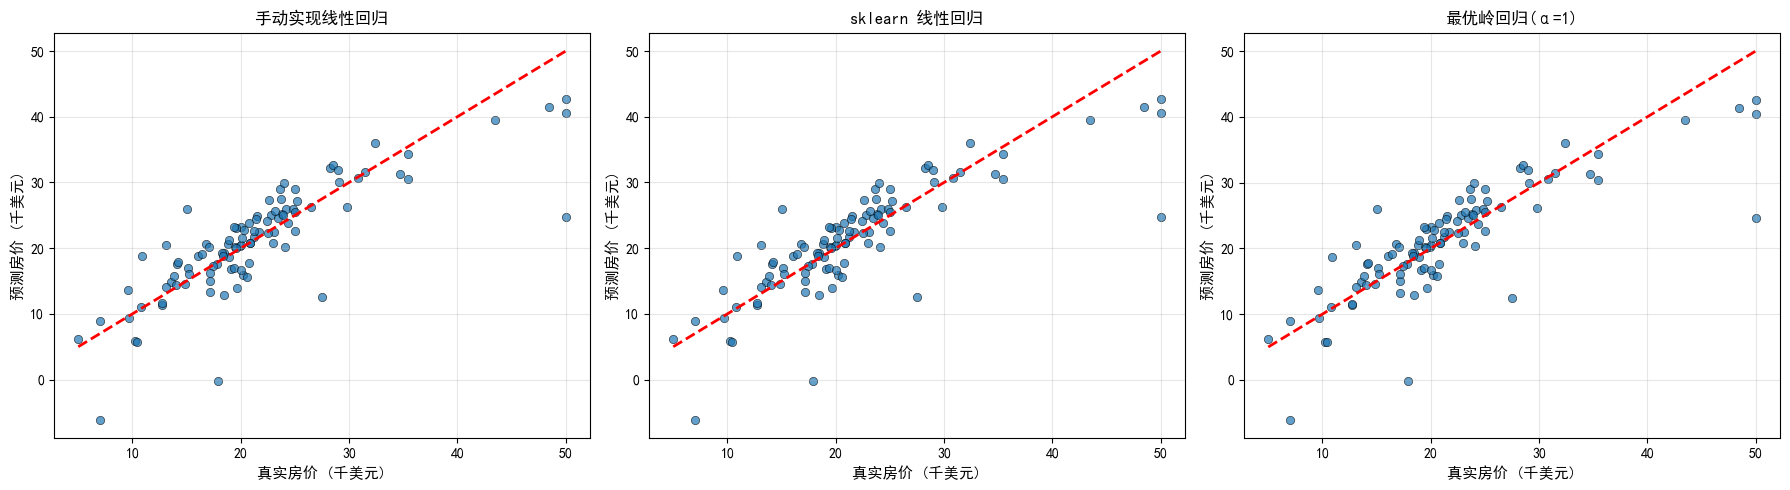

In [11]:
print('\n' + '=' * 60)
print('📈 步骤5：模型性能对比')
print('=' * 60)

results = {
    '手动实现线性回归': evaluate(y_test, y_pred_my, silent=True),
    'sklearn 线性回归': evaluate(y_test, y_pred_lr, silent=True),
    f'最优岭回归(α={grid.best_params_["alpha"]})': evaluate(y_test, y_pred_best, silent=True),
}

print(f"{'模型':<24} {'MAE':>10} {'MSE':>12} {'RMSE':>12} {'R²':>10}")
print('-' * 72)
for model_name, metrics in results.items():
    mae, mse, rmse, r2 = metrics
    print(f'{model_name:<24} {mae:>10.4f} {mse:>12.4f} {rmse:>12.4f} {r2:>10.4f}')

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
predictions = [
    (y_pred_my, '手动实现线性回归', axes[0]),
    (y_pred_lr, 'sklearn 线性回归', axes[1]),
    (y_pred_best, f'最优岭回归(α={grid.best_params_["alpha"]})', axes[2]),
]

for y_pred, title, ax in predictions:
    ax.scatter(y_test, y_pred, alpha=0.7, edgecolors='black', linewidth=0.5)
    ax.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', linewidth=2)
    ax.set_xlabel('真实房价 (千美元)', fontsize=11)
    ax.set_ylabel('预测房价 (千美元)', fontsize=11)
    ax.set_title(title, fontsize=12)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 步骤6：自定义房屋预测

输入一个样例房屋和一个“更优质”的房屋特征组合，观察模型给出的价格差异。

In [12]:
print('\n' + '=' * 60)
print('🏠 步骤6：预测应用 - 自定义房屋特征预测')
print('=' * 60)

feature_ranges = {
    'CRIM': (0.00632, 88.9762),
    'ZN': (0.0, 100.0),
    'INDUS': (0.46, 27.74),
    'CHAS': (0, 1),
    'NOX': (0.385, 0.871),
    'RM': (3.561, 8.78),
    'AGE': (2.9, 100.0),
    'DIS': (1.1296, 12.1265),
    'RAD': (1, 24),
    'TAX': (187, 711),
    'PTRATIO': (12.6, 22.0),
    'B': (0.32, 396.9),
    'LSTAT': (1.73, 37.97),
}

sample = np.array([[0.02731, 0.0, 7.07, 0.0, 0.469, 6.421, 78.9, 4.9671, 2.0, 242.0, 17.8, 396.90, 9.14]])
sample_scaled = scaler.transform(sample)
pred_price = grid.predict(sample_scaled)[0]

print('\n【自定义房屋特征预测示例】')
print('输入特征值：')
for feat, val in zip(feature_names, sample[0]):
    print(f'  {feat}: {val}')
print(f'\n预测房价: {pred_price:.2f} 千美元')

print('\n【预测一个好房子：临河、房间多、低犯罪率】')
good_house = np.array([[0.01, 25.0, 4.0, 1.0, 0.4, 7.5, 30.0, 3.0, 5.0, 300.0, 14.0, 390.0, 3.0]])
good_house_scaled = scaler.transform(good_house)
good_price = grid.predict(good_house_scaled)[0]
print(f'预测房价: {good_price:.2f} 千美元 (通常会更贵)')


🏠 步骤6：预测应用 - 自定义房屋特征预测

【自定义房屋特征预测示例】
输入特征值：
  CRIM: 0.02731
  ZN: 0.0
  INDUS: 7.07
  CHAS: 0.0
  NOX: 0.469
  RM: 6.421
  AGE: 78.9
  DIS: 4.9671
  RAD: 2.0
  TAX: 242.0
  PTRATIO: 17.8
  B: 396.9
  LSTAT: 9.14

预测房价: 25.19 千美元

【预测一个好房子：临河、房间多、低犯罪率】
预测房价: 44.35 千美元 (通常会更贵)


## 实验总结

最后用一段简短总结回顾模型效果、正则化的作用和线性回归的局限。

In [13]:
print('\n' + '=' * 60)
print('📝 实验总结')
print('=' * 60)

print(
    '''
1. 手动实现的线性回归与 sklearn 线性回归结果基本一致，说明最小二乘法实现是正确的。

2. 岭回归通过 L2 正则化压缩权重，能在共线性较强的数据上提供更稳定的结果。

3. R² 表示模型对房价波动的解释比例，数值越接近 1，说明模型拟合能力越强。

4. 线性回归的局限性：
   - 只能拟合线性关系
   - 对异常值敏感
   - 面对强非线性数据时效果有限

5. 可进一步尝试：
   - 多项式回归
   - Lasso 正则化
   - 随机森林、XGBoost 等更复杂模型
'''
)

print('🎉 实验完成！')


📝 实验总结

1. 手动实现的线性回归与 sklearn 线性回归结果基本一致，说明最小二乘法实现是正确的。

2. 岭回归通过 L2 正则化压缩权重，能在共线性较强的数据上提供更稳定的结果。

3. R² 表示模型对房价波动的解释比例，数值越接近 1，说明模型拟合能力越强。

4. 线性回归的局限性：
   - 只能拟合线性关系
   - 对异常值敏感
   - 面对强非线性数据时效果有限

5. 可进一步尝试：
   - 多项式回归
   - Lasso 正则化
   - 随机森林、XGBoost 等更复杂模型

🎉 实验完成！


## 可选：交互式面板

如果你的环境安装了 `ipywidgets`，可以取消最后一行注释来启用交互式面板。

In [3]:
def run_interactive_panels():
    """交互式面板（可独立运行，不依赖前面单元的执行状态）。"""
    try:
        import traceback
        import ipywidgets as widgets
        from IPython.display import display
        import numpy as np
        import pandas as pd
        import matplotlib.pyplot as plt
        import seaborn as sns
        from sklearn.model_selection import train_test_split, GridSearchCV
        from sklearn.preprocessing import StandardScaler
        from sklearn.linear_model import LinearRegression, Ridge
        from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

        plt.rcParams['font.sans-serif'] = ['SimHei', 'DejaVu Sans']
        plt.rcParams['axes.unicode_minus'] = False

        def build_state():
            data_url = 'http://lib.stat.cmu.edu/datasets/boston'
            raw_df = pd.read_csv(data_url, sep='\s+', skiprows=22, header=None)

            data_array = np.hstack([raw_df.values[::2, :], raw_df.values[1::2, :2]])
            target = raw_df.values[1::2, 2]
            feature_names_local = ['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT']

            data_local = pd.DataFrame(data_array, columns=feature_names_local)
            data_local['PRICE'] = target

            X_local = data_local.drop('PRICE', axis=1)
            y_local = data_local['PRICE']

            X_train_local, X_test_local, y_train_local, y_test_local = train_test_split(
                X_local, y_local, test_size=0.2, random_state=42
            )

            scaler_local = StandardScaler()
            X_train_scaled_local = scaler_local.fit_transform(X_train_local)
            X_test_scaled_local = scaler_local.transform(X_test_local)

            ridge_grid_local = GridSearchCV(
                Ridge(),
                {'alpha': [0.001, 0.01, 0.1, 1, 10, 100]},
                cv=5,
                scoring='neg_mean_squared_error',
                return_train_score=True,
            )
            ridge_grid_local.fit(X_train_scaled_local, y_train_local)

            return {
                'data': data_local,
                'feature_names': feature_names_local,
                'X_train_scaled': X_train_scaled_local,
                'X_test_scaled': X_test_scaled_local,
                'y_train': y_train_local,
                'y_test': y_test_local,
                'scaler': scaler_local,
                'grid': ridge_grid_local,
            }

        state = build_state()

        def evaluate(y_true, y_pred):
            mae = mean_absolute_error(y_true, y_pred)
            mse = mean_squared_error(y_true, y_pred)
            rmse = np.sqrt(mse)
            r2 = r2_score(y_true, y_pred)
            return mae, mse, rmse, r2

        feature_selector = widgets.Dropdown(
            options=state['feature_names'],
            value='RM',
            description='选择特征：',
            layout=widgets.Layout(width='420px'),
        )
        eda_btn = widgets.Button(description='绘制分布图+热力图', button_style='info')
        eda_out = widgets.Output(layout=widgets.Layout(border='1px solid #ddd', padding='8px'))

        alpha_slider = widgets.FloatLogSlider(
            base=10,
            min=-3,
            max=3,
            step=0.01,
            value=max(float(state['grid'].best_params_['alpha']), 0.001),
            description='正则化系数：',
            continuous_update=False,
            layout=widgets.Layout(width='520px'),
        )
        train_btn = widgets.Button(description='训练模型并评估', button_style='success')
        train_out = widgets.Output(layout=widgets.Layout(border='1px solid #ddd', padding='8px'))

        default_values = [0.03, 10.0, 5.0, 1, 0.45, 6.5, 60.0, 5.0, 3, 250.0, 16.0, 390.0, 8.0]
        feature_inputs = []
        for i, feat in enumerate(state['feature_names']):
            feature_inputs.append(
                widgets.FloatText(
                    value=default_values[i],
                    description=f'{feat}:',
                    layout=widgets.Layout(width='420px'),
                )
            )
        predict_btn = widgets.Button(description='预测房价', button_style='warning')
        predict_out = widgets.Output(layout=widgets.Layout(border='1px solid #ddd', padding='8px'))

        def eda_visualize(_):
            with eda_out:
                eda_out.clear_output(wait=True)
                try:
                    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

                    axes[0].hist(state['data'][feature_selector.value], bins=20, color='skyblue', edgecolor='black')
                    axes[0].set_title(f'{feature_selector.value} 分布', fontsize=12)
                    axes[0].set_xlabel(feature_selector.value)
                    axes[0].set_ylabel('频数')

                    top_features = state['data'].corr(numeric_only=True)['PRICE'].abs().sort_values(ascending=False).head(8).index
                    sns.heatmap(
                        state['data'][top_features].corr(numeric_only=True),
                        annot=True,
                        fmt='.2f',
                        cmap='coolwarm',
                        center=0,
                        ax=axes[1],
                    )
                    axes[1].set_title('核心特征相关性热力图', fontsize=12)

                    plt.tight_layout()
                    plt.show()
                    plt.close(fig)
                except Exception:
                    print(traceback.format_exc())

        def train_and_evaluate(_):
            with train_out:
                train_out.clear_output(wait=True)
                try:
                    ridge_model = Ridge(alpha=alpha_slider.value)
                    ridge_model.fit(state['X_train_scaled'], state['y_train'])
                    y_pred = ridge_model.predict(state['X_test_scaled'])
                    mae, mse, rmse, r2 = evaluate(state['y_test'], y_pred)

                    ols_model = LinearRegression()
                    ols_model.fit(state['X_train_scaled'], state['y_train'])

                    print(f'岭回归(α={alpha_slider.value:.3f}) 评估结果：')
                    print(f'  MAE : {mae:.4f} 千美元')
                    print(f'  MSE : {mse:.4f}')
                    print(f'  RMSE: {rmse:.4f} 千美元')
                    print(f'  R²  : {r2:.4f}')
                    print('\n提示：预测散点图通常变化不大，系数图更容易看出 alpha 的影响。')

                    fig, axes = plt.subplots(1, 2, figsize=(18, 6))

                    axes[0].scatter(state['y_test'], y_pred, alpha=0.7, edgecolors='black', linewidth=0.5)
                    axes[0].plot(
                        [state['y_test'].min(), state['y_test'].max()],
                        [state['y_test'].min(), state['y_test'].max()],
                        'r--',
                        linewidth=2,
                    )
                    axes[0].set_xlabel('真实房价 (千美元)', fontsize=12)
                    axes[0].set_ylabel('预测房价 (千美元)', fontsize=12)
                    axes[0].set_title(f'真实值 vs 预测值 (α={alpha_slider.value:.3f})', fontsize=13)
                    axes[0].grid(True, alpha=0.3)

                    x_pos = np.arange(len(state['feature_names']))
                    axes[1].bar(x_pos - 0.18, ols_model.coef_, width=0.36, label='OLS', color='#b0b0b0')
                    axes[1].bar(x_pos + 0.18, ridge_model.coef_, width=0.36, label='Ridge', color='#2a9d8f')
                    axes[1].axhline(0, color='black', linewidth=0.8)
                    axes[1].set_xticks(x_pos)
                    axes[1].set_xticklabels(state['feature_names'], rotation=45, ha='right')
                    axes[1].set_ylabel('回归系数', fontsize=12)
                    axes[1].set_title('系数对比：正则化会压缩权重', fontsize=13)
                    axes[1].legend()
                    axes[1].grid(True, axis='y', alpha=0.3)

                    plt.tight_layout()
                    plt.show()
                    plt.close(fig)
                except Exception:
                    print(traceback.format_exc())

        def predict_house_price(_):
            with predict_out:
                predict_out.clear_output(wait=True)
                try:
                    sample = np.array([[inp.value for inp in feature_inputs]])
                    sample_scaled = state['scaler'].transform(sample)
                    price = state['grid'].predict(sample_scaled)[0]
                    print(f'预测结果：该房屋价格为 {price:.2f} 千美元（约 {price * 1000:.0f} 美元）')
                except Exception:
                    print(traceback.format_exc())

        eda_btn.on_click(eda_visualize)
        train_btn.on_click(train_and_evaluate)
        predict_btn.on_click(predict_house_price)

        eda_section = widgets.VBox([
            widgets.HTML('<h3>📊 面板1：数据探索可视化</h3>'),
            widgets.HBox([feature_selector, eda_btn]),
            eda_out,
        ])

        train_section = widgets.VBox([
            widgets.HTML('<h3>⚙️ 面板2：模型参数调优与训练</h3>'),
            alpha_slider,
            train_btn,
            train_out,
        ])

        predict_section = widgets.VBox([
            widgets.HTML('<h3>🏠 面板3：自定义房屋特征，实时预测房价</h3>'),
            widgets.VBox(feature_inputs),
            predict_btn,
            predict_out,
        ])

        display(eda_section, train_section, predict_section)

    except ImportError:
        print('⚠️ 未安装 ipywidgets，跳过交互式面板。')
        print('   如需使用，请运行: pip install ipywidgets')


run_interactive_panels()